# HD-Correlated GWB Likelihood Demo

This notebook demonstrates JaxPINT's **correlated PTA likelihood** — a
two-tier Woodbury scheme that accounts for inter-pulsar correlations via
the Hellings-Downs overlap reduction function (ORF).

We compare three likelihood formulations:
1. **No GWB** — per-pulsar noise only
2. **CURN** — uncorrelated common red noise (same PSD, independent pulsars)
3. **HD-correlated GWB** — Hellings-Downs inter-pulsar correlations

All three use realistic synthetic pulsars with white noise, ECORR, and
intrinsic power-law red noise.

In [1]:
from __future__ import annotations

import logging
import warnings
from io import StringIO

from loguru import logger
logger.disable("pint")

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import astropy.units as u
import pint.models as pm
import pint.simulation as psim

from jaxpint import build_timing_model, pint_toas_to_jax
from jaxpint.bridge.model_conversion import pint_model_to_params
from jaxpint.pta.likelihood import PTAConfig, pta_logL
from jaxpint.pta.correlated_likelihood import (
    CorrelatedPTAConfig,
    pta_logL_correlated,
)
from jaxpint.pta.params import GlobalParams
from jaxpint.pta.signals.gwb import CURNInjector
from jaxpint.pta.signals.correlated_gwb import HDCorrelatedGWBInjector
from jaxpint.pta.signals.orf import hd_orf

jax.config.update("jax_enable_x64", True)

# ---- Configuration ----
N_PULSARS = 10
N_TOAS = 200
GLOBAL_START_MJD = 55000.0
GLOBAL_END_MJD = 61000.0
MIN_SPAN_DAYS = 1500.0
TOA_ERROR = 1e-8        # 10 ns
FREQ = 1400.0           # MHz
SEED = 42

# GWB parameters (NANOGrav 15yr)
GWB_LOG10_A = -14.6
GWB_GAMMA = 13.0 / 3.0
GWB_N_COMPONENTS = 14

## Generate synthetic pulsars with realistic noise

Each pulsar has its own sky position, spindown, and noise parameters
(EFAC, EQUAD, ECORR, power-law red noise).

In [2]:
rng = np.random.default_rng(SEED)


def random_obs_window(rng):
    start = rng.uniform(GLOBAL_START_MJD, GLOBAL_END_MJD - MIN_SPAN_DAYS)
    end = rng.uniform(start + MIN_SPAN_DAYS, GLOBAL_END_MJD)
    return start, end


def generate_random_par(idx, start_mjd, rng):
    ra_hours = rng.uniform(0, 24)
    dec_deg = np.degrees(np.arcsin(rng.uniform(-1, 1)))

    ra_h = int(ra_hours)
    ra_m = int((ra_hours - ra_h) * 60)
    ra_s = (ra_hours - ra_h - ra_m / 60) * 3600

    dec_sign = "+" if dec_deg >= 0 else "-"
    dec_abs = abs(dec_deg)
    dec_d = int(dec_abs)
    dec_m = int((dec_abs - dec_d) * 60)
    dec_s = (dec_abs - dec_d - dec_m / 60) * 3600

    f0 = rng.uniform(100, 500)
    f1 = -10 ** rng.uniform(-16, -14)
    dm = rng.uniform(10, 50)
    px_kpc = rng.uniform(0.5, 3.0)
    tnredamp = rng.uniform(-15, -12)
    tnredgam = rng.uniform(1.5, 5.0)
    ecorr_us = rng.uniform(0.01, 1.0)

    return f"""\
PSR           J{ra_h:02d}{ra_m:02d}{dec_sign}{dec_d:02d}{dec_m:02d}_{idx:02d}
RAJ           {ra_h:02d}:{ra_m:02d}:{ra_s:08.5f}
DECJ          {dec_sign}{dec_d:02d}:{dec_m:02d}:{dec_s:07.4f}
F0            {f0:.10f}
F1            {f1:.6e}
PEPOCH        {start_mjd:.1f}
DM            {dm:.4f}
PX            {px_kpc:.4f}
EPHEM         DE440
CLK           TT(BIPM2019)
UNITS         TDB
EFAC tel gbt 1.0
EQUAD tel gbt 0.1
ECORR tel gbt {ecorr_us:.4f}
TNRedAmp {tnredamp:.6f}
TNRedGam {tnredgam:.6f}
TNRedC 14
"""


def generate_irregular_mjds(start, end, n_approx, rng):
    avg_gap = (end - start) / n_approx
    mjds = [start]
    while mjds[-1] < end:
        gap = rng.exponential(avg_gap)
        mjds.append(mjds[-1] + gap)
    mjds = np.array(mjds[:-1])
    return mjds[mjds < end]


obs_windows = [random_obs_window(rng) for _ in range(N_PULSARS)]
par_strings = [generate_random_par(i, s, rng) for i, (s, e) in enumerate(obs_windows)]
pint_models = [pm.get_model(StringIO(p)) for p in par_strings]

# Convert to JaxPINT
toa_data_list = []
pulsar_params_list = []
timing_models = []
noise_models = []

for i, model in enumerate(pint_models):
    start_i, end_i = obs_windows[i]
    mjds = generate_irregular_mjds(start_i, end_i, N_TOAS, rng)
    toas = psim.make_fake_toas_fromMJDs(
        mjds, model, obs="GBT", error=TOA_ERROR * u.s, freq=FREQ * u.MHz,
    )
    toa_data = pint_toas_to_jax(toas, model)
    par_result = pint_model_to_params(model)
    tm, nm = build_timing_model(model, toas)

    toa_data_list.append(toa_data)
    pulsar_params_list.append(par_result.params)
    timing_models.append(tm)
    noise_models.append(nm)

pp_tuple = tuple(pulsar_params_list)

# Extract pulsar sky positions
positions = []
for model in pint_models:
    ra_rad = model.RAJ.quantity.to(u.rad).value
    dec_rad = model.DECJ.quantity.to(u.rad).value
    pos = np.array([
        np.cos(dec_rad) * np.cos(ra_rad),
        np.cos(dec_rad) * np.sin(ra_rad),
        np.sin(dec_rad),
    ])
    positions.append(pos)
positions = jnp.array(np.array(positions))

T_span_s = (GLOBAL_END_MJD - GLOBAL_START_MJD) * 86400.0

print(f"Generated {N_PULSARS} pulsars:")
for i, (s, e) in enumerate(obs_windows):
    n = toa_data_list[i].n_toas
    print(f"  Pulsar {i}: {pint_models[i].PSR.value:>20s}  "
          f"n_toas={n:3d}  MJD {s:.0f}-{e:.0f}")
print(f"\nT_span = {T_span_s/3.156e7:.1f} yr")

/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)
/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)


Generated 10 pulsars:
  Pulsar 0:        J1811-1654_00  n_toas=213  MJD 58483-60429
  Pulsar 1:        J1623+2918_01  n_toas=185  MJD 58864-60807
  Pulsar 2:        J0526+1951_02  n_toas=186  MJD 55424-60901
  Pulsar 3:        J0655+2124_03  n_toas=193  MJD 58425-60770
  Pulsar 4:        J1100+0754_04  n_toas=217  MJD 55577-58844
  Pulsar 5:        J1317+0648_05  n_toas=196  MJD 56669-60793
  Pulsar 6:        J0123-2555_06  n_toas=192  MJD 57897-60716
  Pulsar 7:        J0400-7239_07  n_toas=185  MJD 56995-59065
  Pulsar 8:        J1042-1345_08  n_toas=192  MJD 57496-59124
  Pulsar 9:        J1647-2755_09  n_toas=223  MJD 58724-60714

T_span = 16.4 yr


## Visualize the Hellings-Downs ORF matrix

The HD ORF encodes inter-pulsar correlations as a function of angular
separation. The diagonal is ~0.5 (auto-correlation); off-diagonal values
range from roughly -0.15 to +0.5.

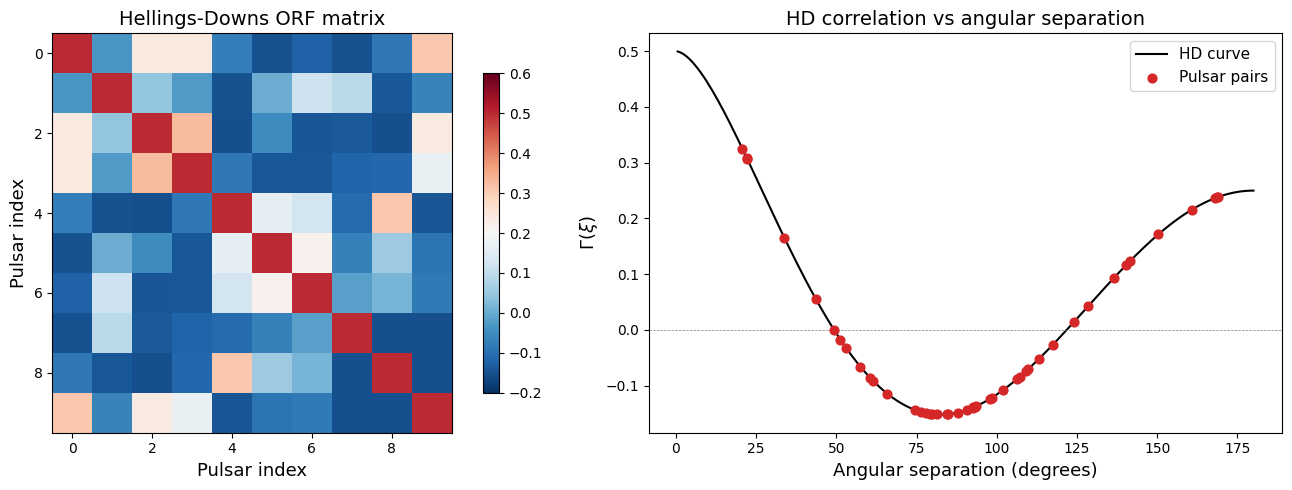

In [3]:
# Build the HD-correlated GWB injector
hd_gwb = HDCorrelatedGWBInjector(
    pulsar_positions=positions,
    n_components=GWB_N_COMPONENTS,
    T_span=T_span_s,
    orf_func=hd_orf,
    initial_values={"log10_A": GWB_LOG10_A, "gamma": GWB_GAMMA},
)

Gamma = np.array(hd_gwb.get_orf_matrix())

# Angular separations for the HD curve
xi_grid = np.linspace(0.01, np.pi, 200)
x_grid = (1 - np.cos(xi_grid)) / 2
hd_curve = 1.5 * x_grid * np.log(x_grid) - 0.25 * x_grid + 0.5

# Compute angular separations for each pulsar pair
pos_np = np.array(positions)
pair_angles = []
pair_gammas = []
for a in range(N_PULSARS):
    for b in range(a + 1, N_PULSARS):
        cos_xi = np.dot(pos_np[a], pos_np[b])
        pair_angles.append(np.arccos(np.clip(cos_xi, -1, 1)))
        pair_gammas.append(Gamma[a, b])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: ORF matrix heatmap
im = axes[0].imshow(Gamma, cmap="RdBu_r", vmin=-0.2, vmax=0.6)
axes[0].set_xlabel("Pulsar index", fontsize=13)
axes[0].set_ylabel("Pulsar index", fontsize=13)
axes[0].set_title("Hellings-Downs ORF matrix", fontsize=14)
fig.colorbar(im, ax=axes[0], shrink=0.8)

# Right: HD curve with pulsar pair values
axes[1].plot(np.degrees(xi_grid), hd_curve, "k-", linewidth=1.5, label="HD curve")
axes[1].scatter(np.degrees(pair_angles), pair_gammas, c="tab:red", s=40,
                zorder=5, label="Pulsar pairs")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=0.5)
axes[1].set_xlabel("Angular separation (degrees)", fontsize=13)
axes[1].set_ylabel(r"$\Gamma(\xi)$", fontsize=13)
axes[1].set_title("HD correlation vs angular separation", fontsize=14)
axes[1].legend(fontsize=11)

fig.tight_layout()
plt.show()

## Set up three likelihood configurations

1. **No GWB**: `pta_logL` with no signal injectors
2. **CURN**: `pta_logL` with `CURNInjector` (uncorrelated common red noise)
3. **HD-correlated**: `pta_logL_correlated` with `HDCorrelatedGWBInjector`

In [4]:
# 1. No GWB
config_none = PTAConfig(
    toa_data_list=tuple(toa_data_list),
    timing_models=tuple(timing_models),
    noise_models=tuple(noise_models),
    signal_injectors=(),
)
gp_none = GlobalParams.empty()

# 2. CURN (uncorrelated common red noise)
curn = CURNInjector(
    n_components=GWB_N_COMPONENTS,
    T_span=T_span_s,
    initial_values={"log10_A": GWB_LOG10_A, "gamma": GWB_GAMMA},
)
gp_curn = curn.register_params(GlobalParams.empty())

config_curn = PTAConfig(
    toa_data_list=tuple(toa_data_list),
    timing_models=tuple(timing_models),
    noise_models=tuple(noise_models),
    signal_injectors=(curn,),
)

# 3. HD-correlated GWB (hd_gwb already created above)
gp_hd = hd_gwb.register_params(GlobalParams.empty())

config_hd = CorrelatedPTAConfig(
    toa_data_list=tuple(toa_data_list),
    timing_models=tuple(timing_models),
    noise_models=tuple(noise_models),
    signal_injectors=(),
    correlated_injectors=(hd_gwb,),
)

print("Configurations ready:")
print(f"  No GWB:       {gp_none.n_params} global params")
print(f"  CURN:         {gp_curn.n_params} global params ({gp_curn.names})")
print(f"  HD-correlated: {gp_hd.n_params} global params ({gp_hd.names})")

Configurations ready:
  No GWB:       0 global params
  CURN:         2 global params (('gwb_log10_A', 'gwb_gamma'))
  HD-correlated: 2 global params (('gwb_log10_A', 'gwb_gamma'))


/tmp/ipykernel_84107/4155661793.py:2: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  config_none = PTAConfig(
/tmp/ipykernel_84107/4155661793.py:18: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  config_curn = PTAConfig(
/tmp/ipykernel_84107/4155661793.py:28: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  config_hd = CorrelatedPTAConfig(


## Evaluate likelihoods at the true parameters

Quick sanity check: all three should produce finite log-likelihood values.

In [5]:
logL_none = float(pta_logL(gp_none, pp_tuple, config_none))
logL_curn = float(pta_logL(gp_curn, pp_tuple, config_curn))
logL_hd = float(pta_logL_correlated(gp_hd, pp_tuple, config_hd))

print(f"Log-likelihood at true parameters:")
print(f"  No GWB:        {logL_none:>20.4f}")
print(f"  CURN:          {logL_curn:>20.4f}")
print(f"  HD-correlated: {logL_hd:>20.4f}")
print(f"\n  CURN - No GWB: {logL_curn - logL_none:>+20.4f}")
print(f"  HD   - CURN:   {logL_hd - logL_curn:>+20.4f}")

Log-likelihood at true parameters:
  No GWB:                  29615.5123
  CURN:                    29541.0823
  HD-correlated:           29556.9766

  CURN - No GWB:             -74.4300
  HD   - CURN:               +15.8943


## Sweep GWB amplitude: CURN vs HD-correlated

Sweep `log10_A` while holding `gamma` fixed. This shows how the two
likelihood formulations respond differently to GWB amplitude.

In [6]:
log10_A_grid = np.linspace(-16.0, -13.0, 80)


# CURN sweep
def curn_logL_at_A(log10_A):
    gp = gp_curn.with_value("gwb_log10_A", log10_A)
    return pta_logL(gp, pp_tuple, config_curn)


# HD sweep
def hd_logL_at_A(log10_A):
    gp = gp_hd.with_value("gwb_log10_A", log10_A)
    return pta_logL_correlated(gp, pp_tuple, config_hd)


curn_vmap = jax.jit(jax.vmap(curn_logL_at_A))
hd_vmap = jax.jit(jax.vmap(hd_logL_at_A))

# Warm up JIT
_ = curn_vmap(jnp.asarray(log10_A_grid[:2])).block_until_ready()
_ = hd_vmap(jnp.asarray(log10_A_grid[:2])).block_until_ready()

print("Sweeping log10_A...")
logL_curn_sweep = np.asarray(curn_vmap(jnp.asarray(log10_A_grid)))
logL_hd_sweep = np.asarray(hd_vmap(jnp.asarray(log10_A_grid)))
print("Done.")

Sweeping log10_A...
Done.


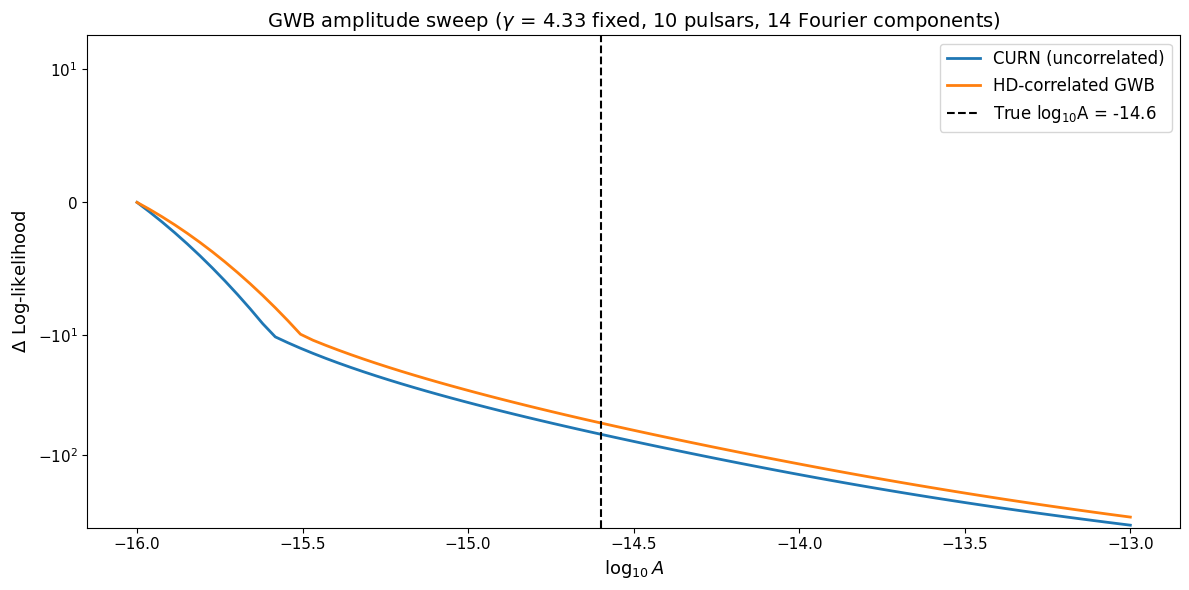

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

delta_curn = logL_curn_sweep - logL_curn_sweep.max()
delta_hd = logL_hd_sweep - logL_hd_sweep.max()

ax.plot(log10_A_grid, delta_curn, linewidth=2, label="CURN (uncorrelated)")
ax.plot(log10_A_grid, delta_hd, linewidth=2, label="HD-correlated GWB")
ax.axvline(GWB_LOG10_A, color="black", linestyle="--", linewidth=1.5,
           label=f"True log$_{{10}}$A = {GWB_LOG10_A}")

ax.set_xlabel(r"$\log_{10} A$", fontsize=13)
ax.set_ylabel(r"$\Delta$ Log-likelihood", fontsize=13)
ax.set_title(
    f"GWB amplitude sweep ($\\gamma$ = {GWB_GAMMA:.2f} fixed, "
    f"{N_PULSARS} pulsars, {GWB_N_COMPONENTS} Fourier components)",
    fontsize=14,
)
ax.set_yscale("symlog", linthresh=10)
ax.legend(fontsize=12)
ax.tick_params(labelsize=11)
fig.tight_layout()
plt.show()

## 2D likelihood surface: log10_A vs gamma

Sweep both GWB parameters to visualize the joint likelihood surface
under the HD-correlated model.

In [8]:
A_grid = np.linspace(-16.0, -13.5, 40)
gamma_grid = np.linspace(2.0, 7.0, 40)


def hd_logL_at_A_gamma(log10_A, gamma):
    gp = gp_hd.with_value("gwb_log10_A", log10_A)
    gp = gp.with_value("gwb_gamma", gamma)
    return pta_logL_correlated(gp, pp_tuple, config_hd)


# Vectorize across the 2D grid in one JIT'd call.
# Outer vmap over gamma (rows), inner vmap over log10_A (cols).
hd_eval_grid = jax.jit(
    jax.vmap(
        jax.vmap(hd_logL_at_A_gamma, in_axes=(0, None)),
        in_axes=(None, 0),
    )
)

# Warm up
_ = hd_eval_grid(
    jnp.asarray(A_grid[:2]),
    jnp.asarray(gamma_grid[:2]),
).block_until_ready()

print("Computing 2D likelihood surface...")
logL_2d = np.asarray(hd_eval_grid(jnp.asarray(A_grid), jnp.asarray(gamma_grid)))
print("Done.")

Computing 2D likelihood surface...
Done.


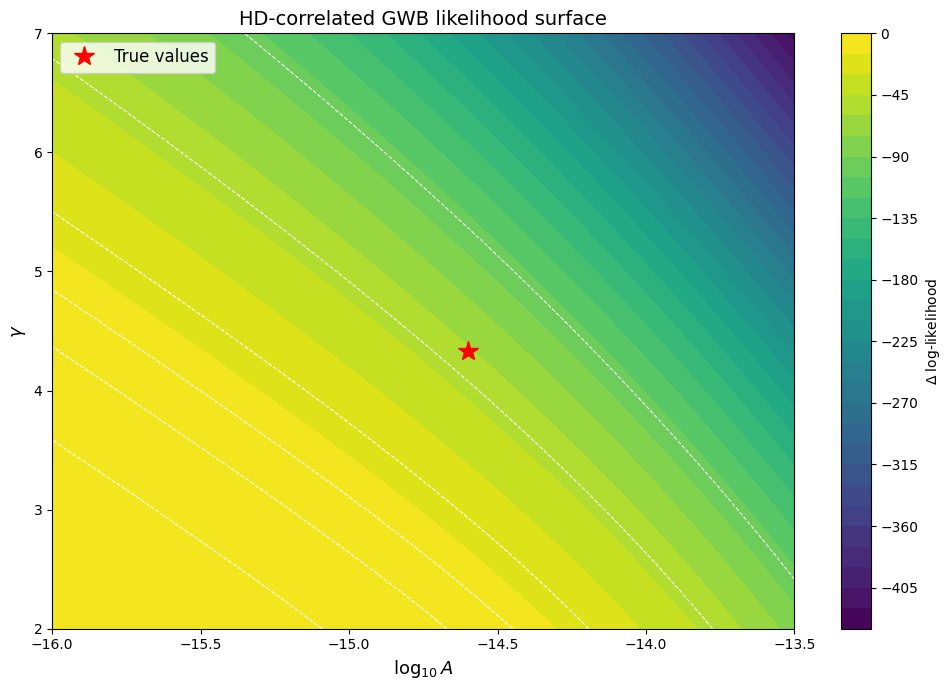

In [9]:
fig, ax = plt.subplots(figsize=(10, 7))

delta_2d = logL_2d - logL_2d.max()
# Clip for better visualization
delta_2d = np.clip(delta_2d, -500, 0)

cf = ax.contourf(A_grid, gamma_grid, delta_2d, levels=30, cmap="viridis")
ax.contour(A_grid, gamma_grid, delta_2d,
           levels=[-100, -50, -20, -10, -5, -1], colors="white",
           linewidths=0.8, linestyles="--")

ax.plot(GWB_LOG10_A, GWB_GAMMA, "r*", markersize=15, label="True values")
ax.set_xlabel(r"$\log_{10} A$", fontsize=13)
ax.set_ylabel(r"$\gamma$", fontsize=13)
ax.set_title("HD-correlated GWB likelihood surface", fontsize=14)
ax.legend(fontsize=12, loc="upper left")
fig.colorbar(cf, ax=ax, label=r"$\Delta$ log-likelihood")
fig.tight_layout()
plt.show()

## Difference between CURN and HD-correlated likelihoods

The difference `logL_HD - logL_CURN` isolates the effect of inter-pulsar
correlations. This is analogous to what the optimal statistic measures.

Computing CURN 2D surface...


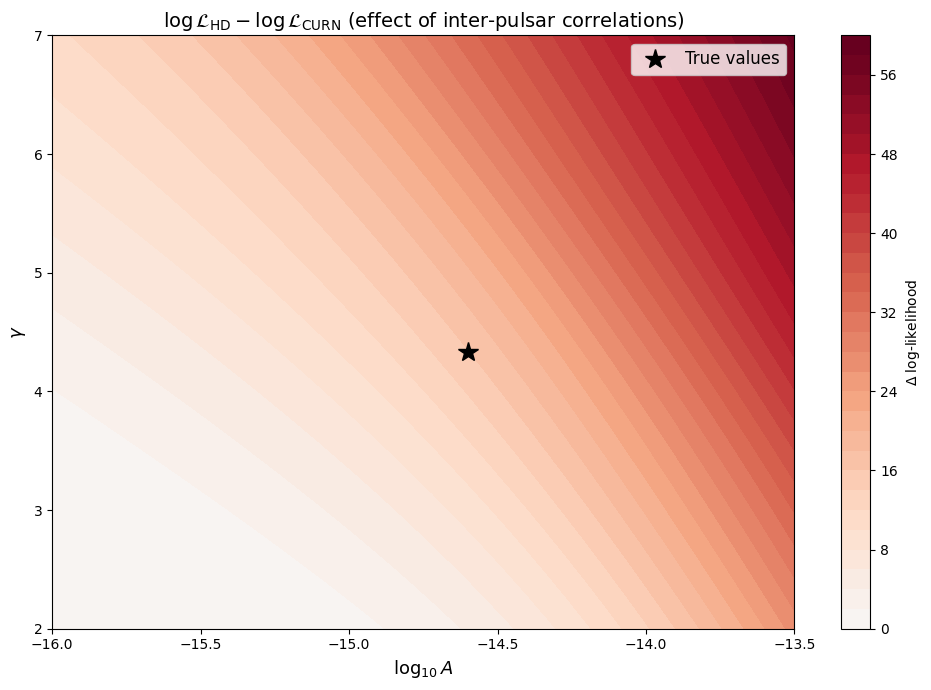

In [10]:
# Compute CURN on the same 2D grid
def curn_logL_at_A_gamma(log10_A, gamma):
    gp = gp_curn.with_value("gwb_log10_A", log10_A)
    gp = gp.with_value("gwb_gamma", gamma)
    return pta_logL(gp, pp_tuple, config_curn)


curn_eval_grid = jax.jit(
    jax.vmap(
        jax.vmap(curn_logL_at_A_gamma, in_axes=(0, None)),
        in_axes=(None, 0),
    )
)

_ = curn_eval_grid(
    jnp.asarray(A_grid[:2]),
    jnp.asarray(gamma_grid[:2]),
).block_until_ready()

print("Computing CURN 2D surface...")
logL_curn_2d = np.asarray(
    curn_eval_grid(jnp.asarray(A_grid), jnp.asarray(gamma_grid))
)

diff_2d = logL_2d - logL_curn_2d

fig, ax = plt.subplots(figsize=(10, 7))
vmax = max(abs(diff_2d.min()), abs(diff_2d.max()))
cf = ax.contourf(A_grid, gamma_grid, diff_2d, levels=30, cmap="RdBu_r",
                 vmin=-vmax, vmax=vmax)
ax.plot(GWB_LOG10_A, GWB_GAMMA, "k*", markersize=15, label="True values")
ax.set_xlabel(r"$\log_{10} A$", fontsize=13)
ax.set_ylabel(r"$\gamma$", fontsize=13)
ax.set_title(r"$\log\mathcal{L}_\mathrm{HD} - \log\mathcal{L}_\mathrm{CURN}$"
             " (effect of inter-pulsar correlations)", fontsize=14)
ax.legend(fontsize=12)
fig.colorbar(cf, ax=ax, label=r"$\Delta$ log-likelihood")
fig.tight_layout()
plt.show()